# UK Default Classification

This notebook packages the second machine learning assignment into a cleaner credit-risk classification project. The goal is to compare a logistic benchmark against tree-based, neural-network, and boosting classifiers.

## Setup

The target is a binary default indicator. The main features are `wkta`, `reta`, `ebitta`, and `mv`. Because the data are imbalanced, the main validation metric is the $F_2$ score, which puts more weight on recall than precision.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

PROJECT_DIR = Path.cwd().resolve().parent
pd.set_option("display.float_format", lambda value: f"{value:0.4f}")

summary = pd.read_csv(PROJECT_DIR / "outputs" / "table_1_summary_statistics.csv")
table_2 = pd.read_csv(PROJECT_DIR / "outputs" / "table_2_model_comparison.csv")
table_3 = pd.read_csv(PROJECT_DIR / "outputs" / "table_3_small_tree_comparison.csv")
class_year = pd.read_csv(PROJECT_DIR / "outputs" / "class_year_distribution.csv")

## Preprocessing

The cleaned dataset removes missing values but keeps the economically meaningful outliers, because many of the most extreme cases are precisely the firms that default.

In [2]:
summary
class_year.tail()

,year,observations,defaults
17,1998,60,2
18,1999,74,20
19,2000,79,16
20,2001,668,30
21,2002,34,34


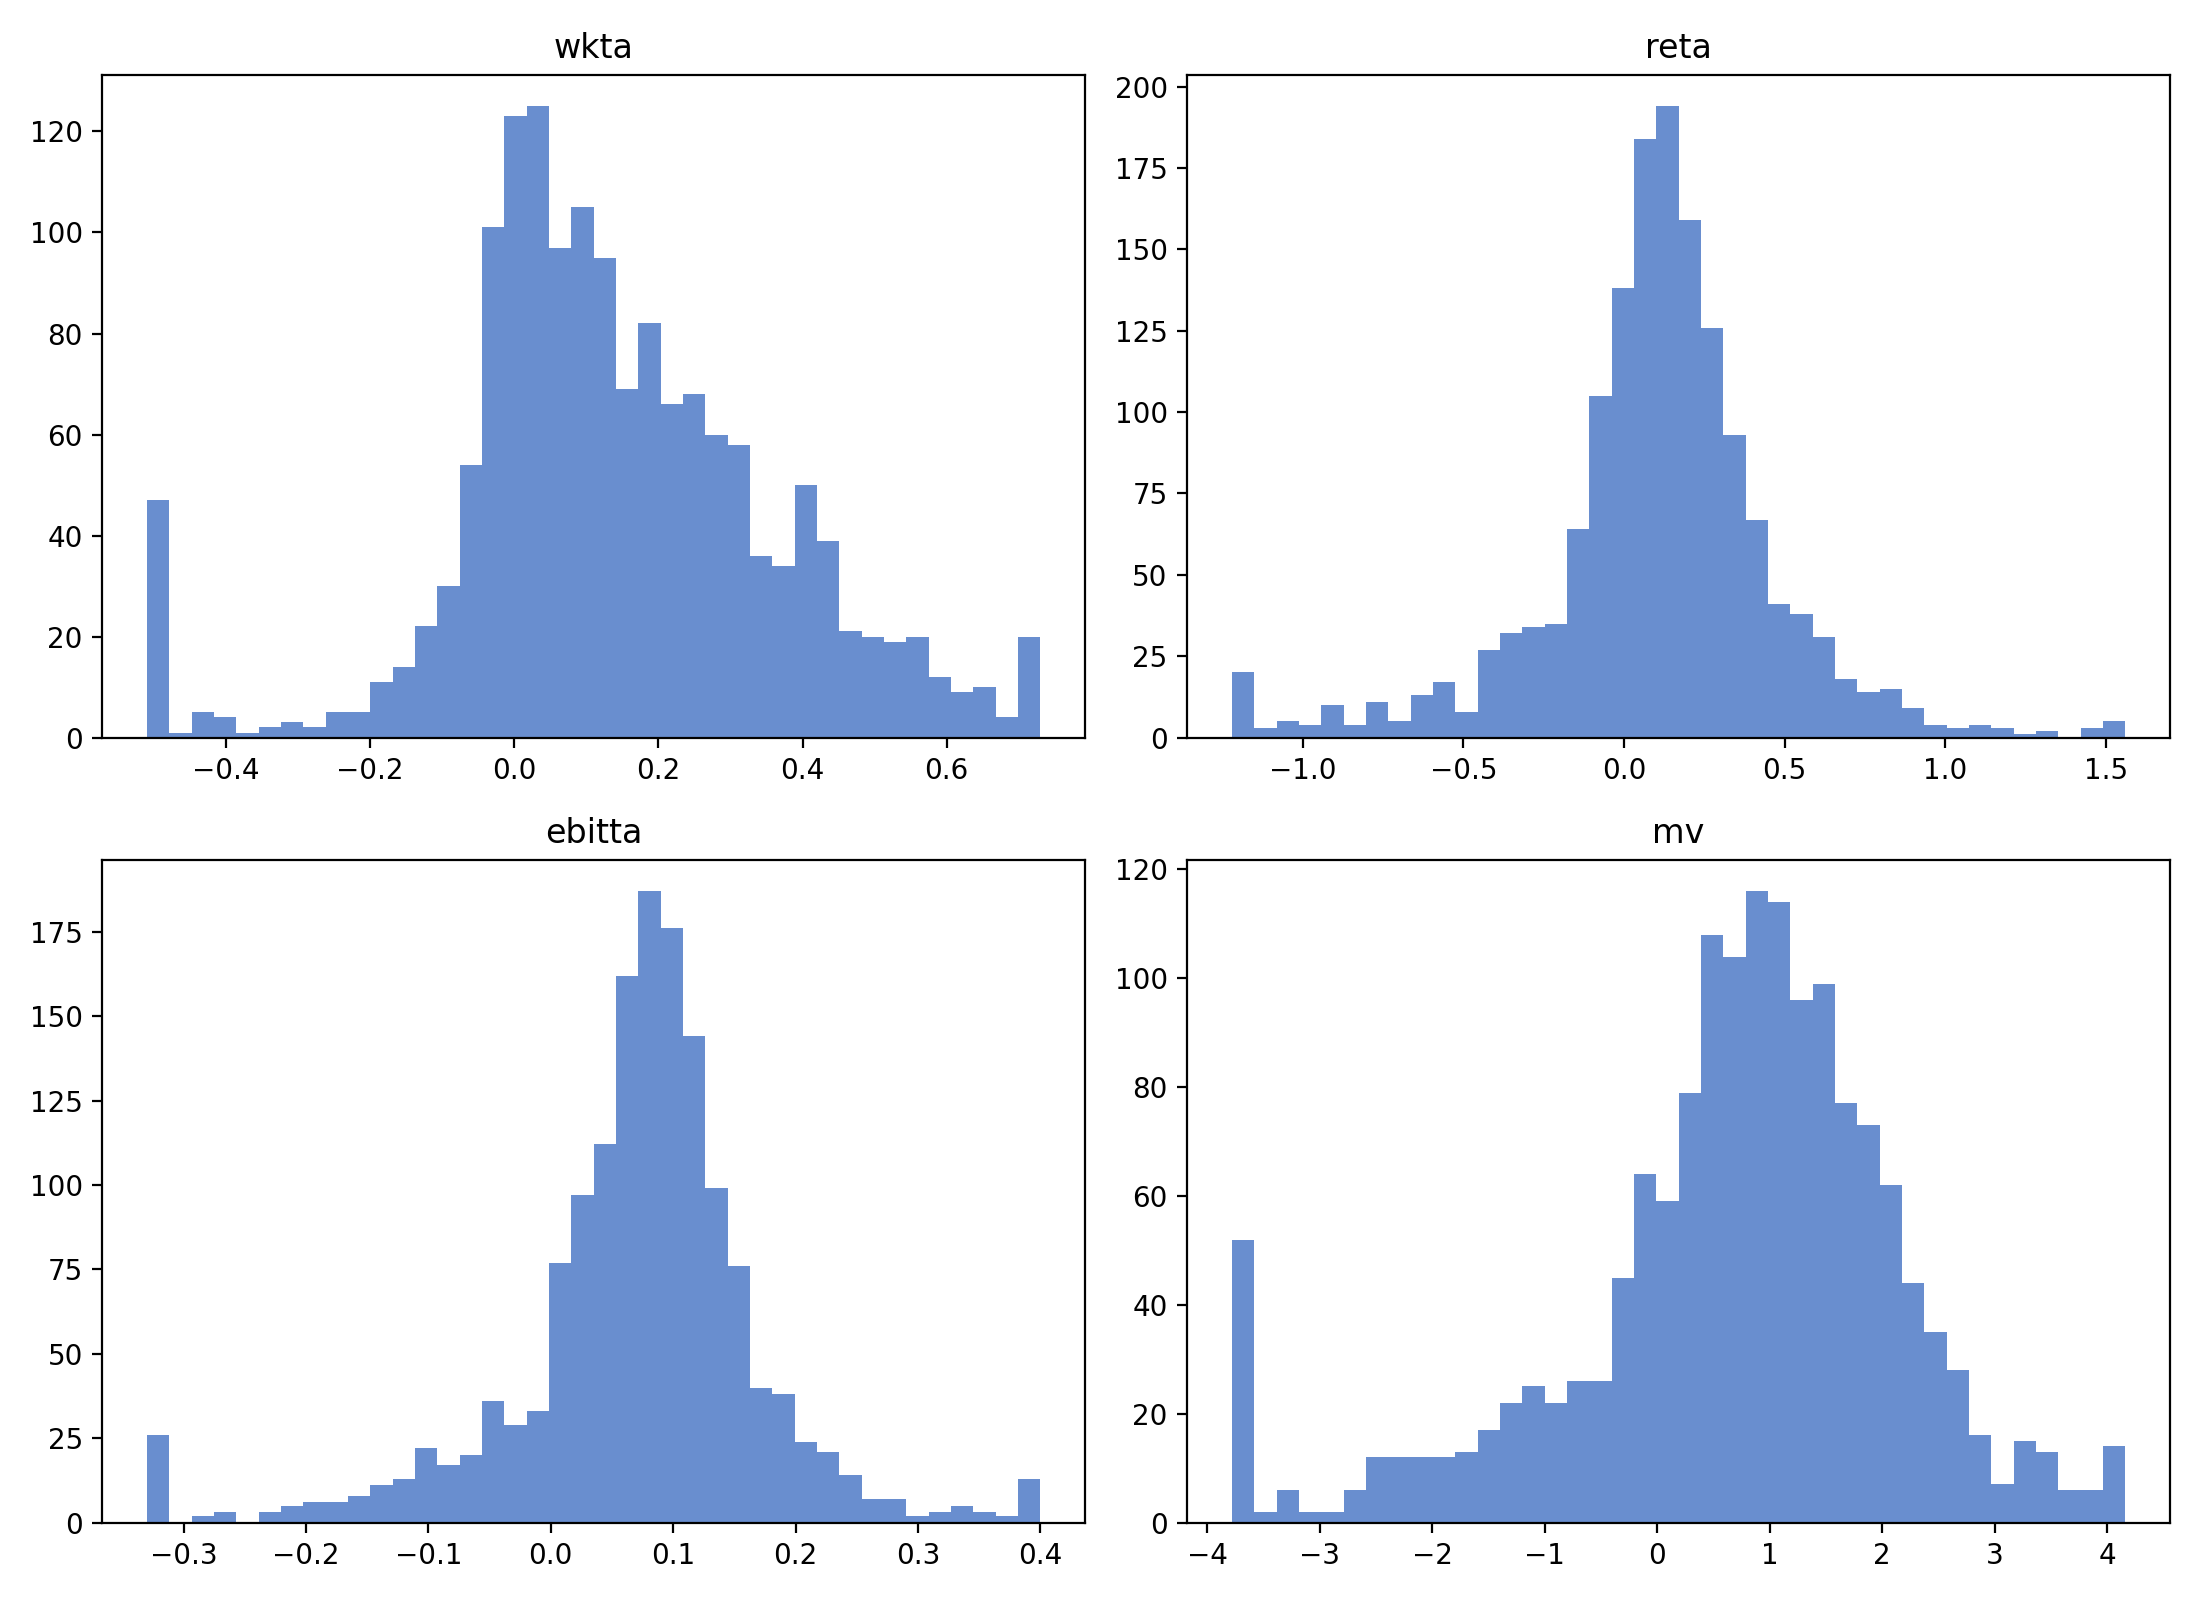

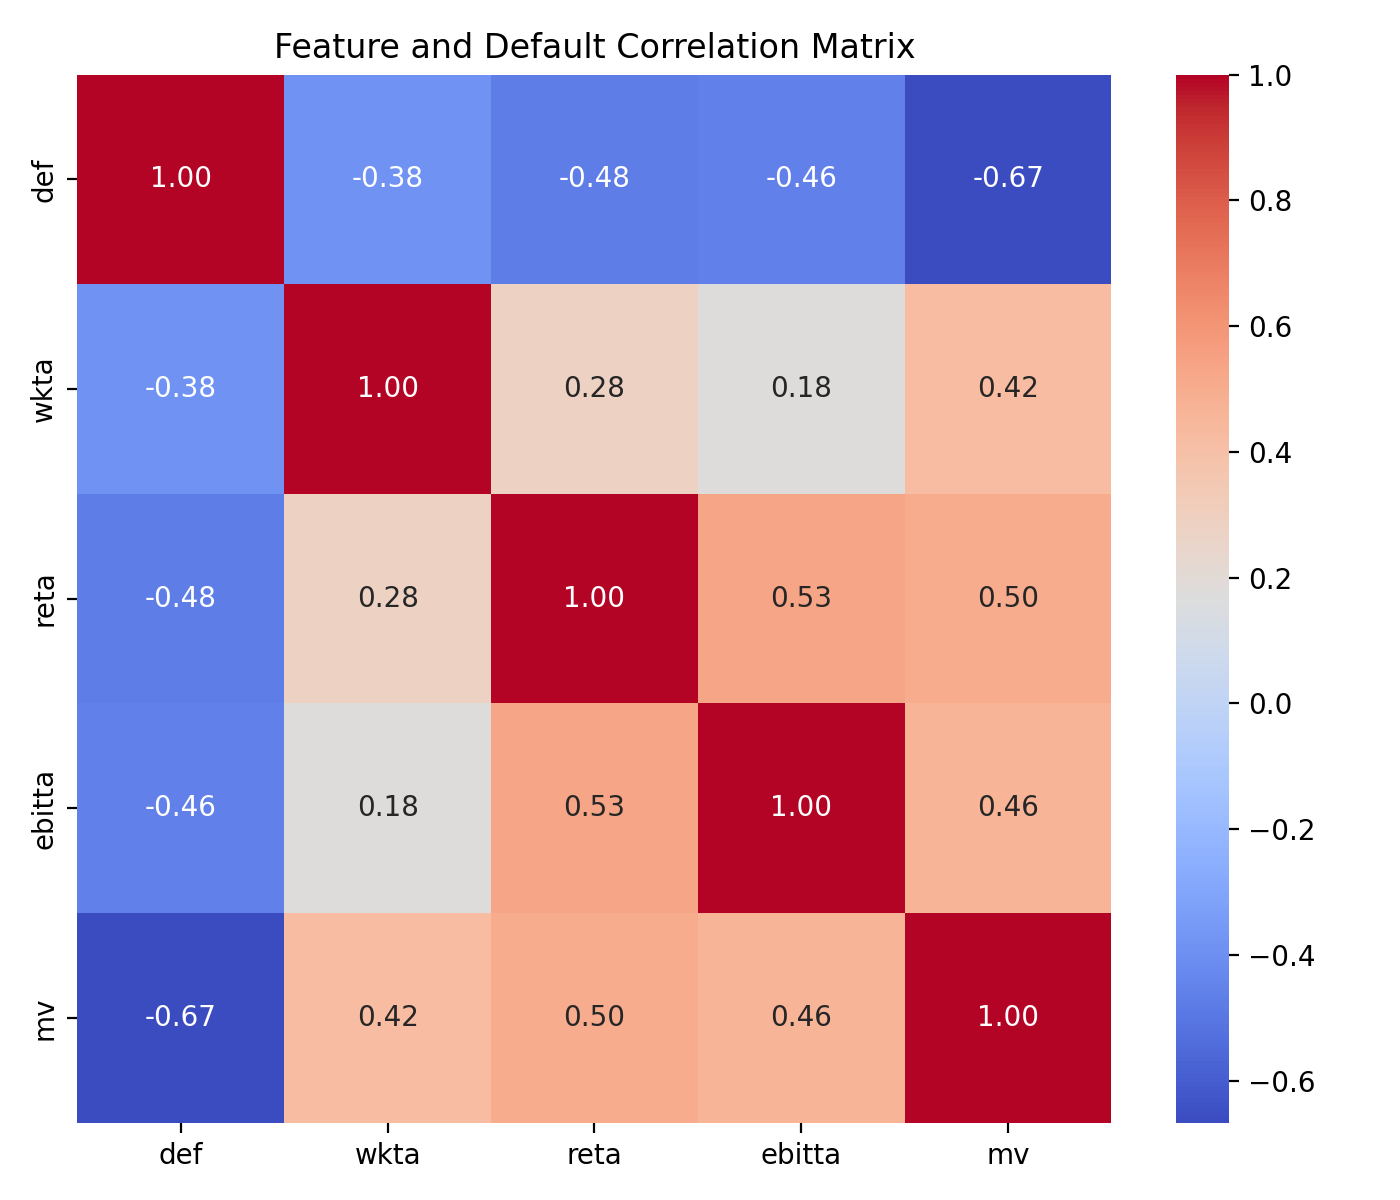

In [3]:
display(Image(filename=str(PROJECT_DIR / "figures" / "feature_distributions.png")))

display(Image(filename=str(PROJECT_DIR / "figures" / "correlation_matrix.png")))

## Main Model Comparison

The main split is 60/20/20 with stratification by year. The benchmark is logistic regression, followed by a tuned decision tree, a small neural network, and gradient boosting.

In [4]:
table_2

,Model,Accuracy,Recall,Precision,F1,F_beta
0,Logistic Regression,0.9452,0.9286,0.6341,0.7536,0.8497
1,Neural Network,0.9548,0.8929,0.6944,0.7812,0.8446
2,Gradient Boosting,0.9484,0.7143,0.7143,0.7143,0.7143
3,Decision Tree,0.9290,0.7500,0.5833,0.6562,0.7095


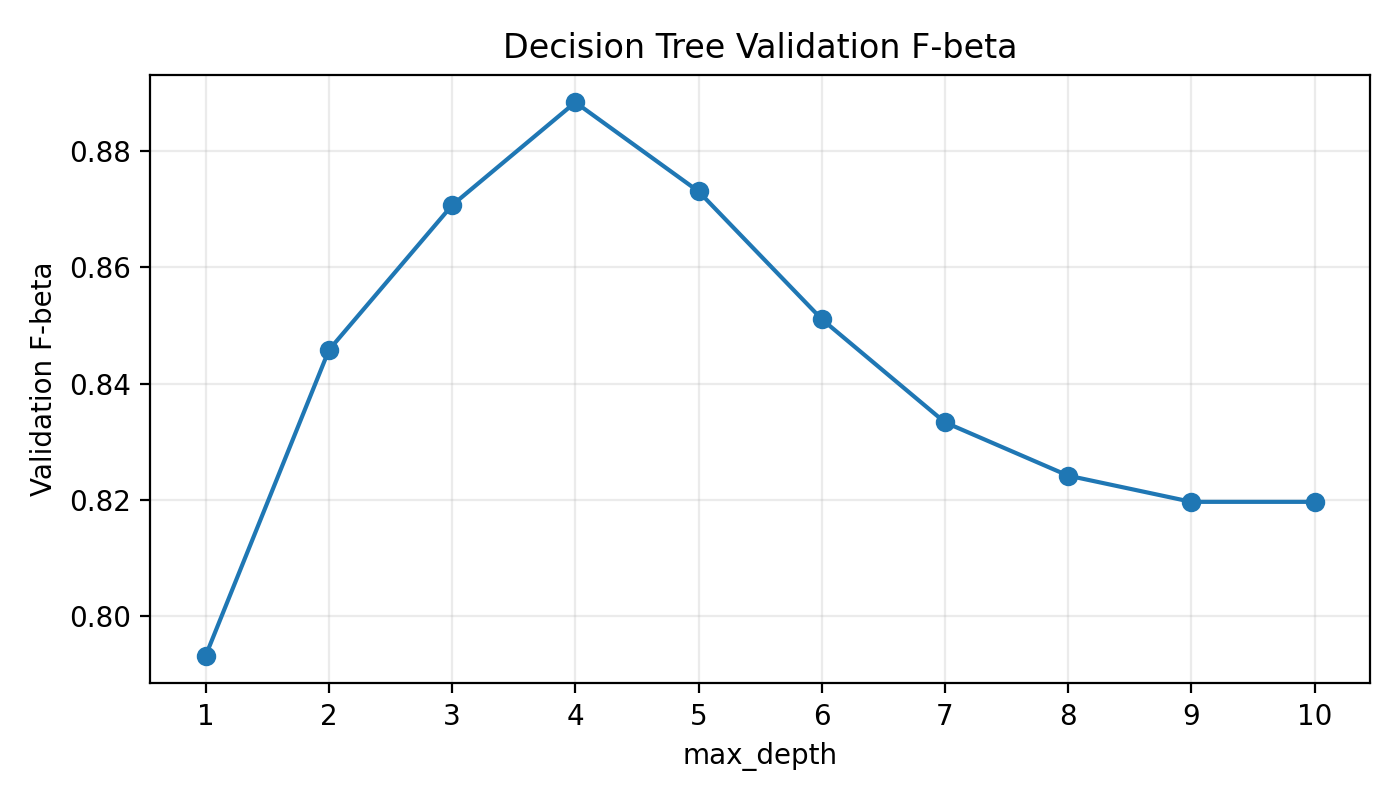

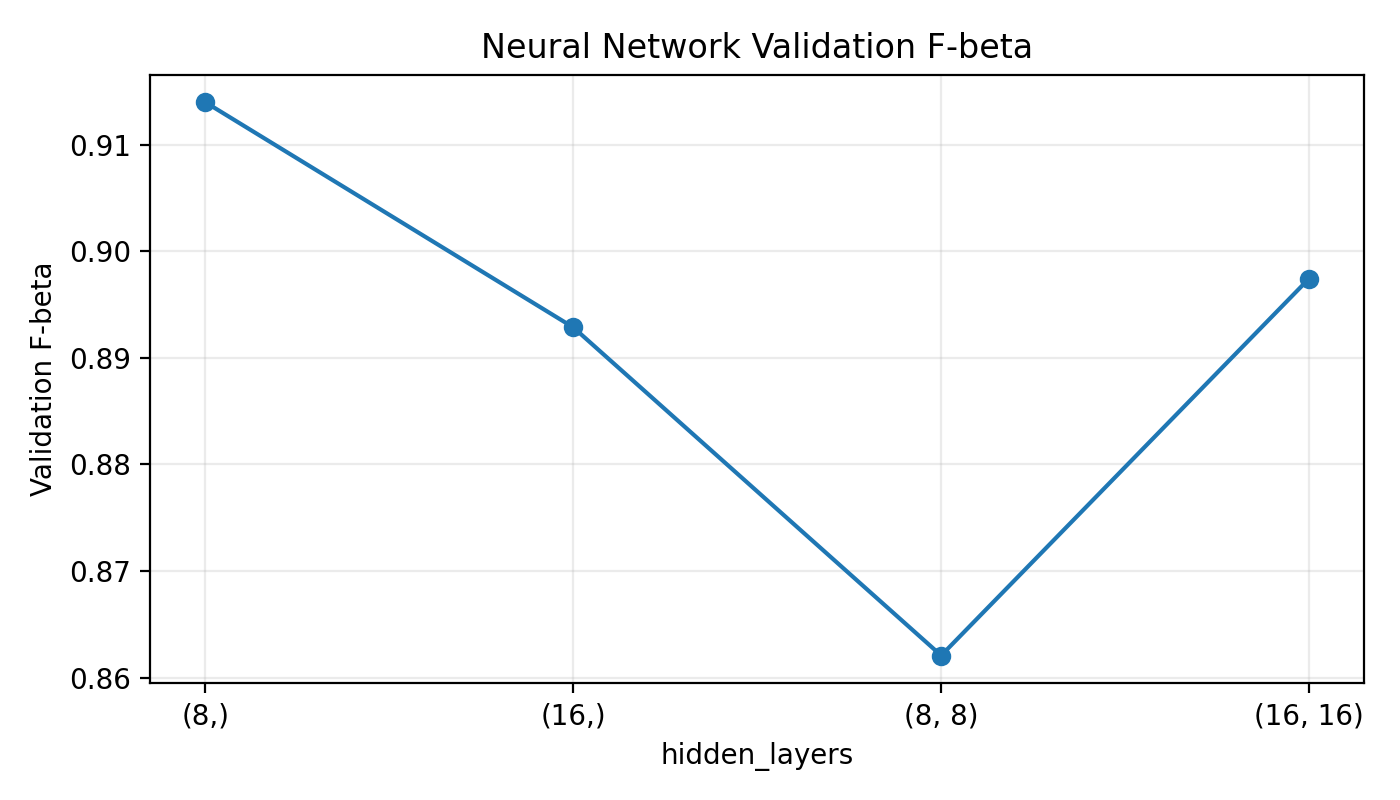

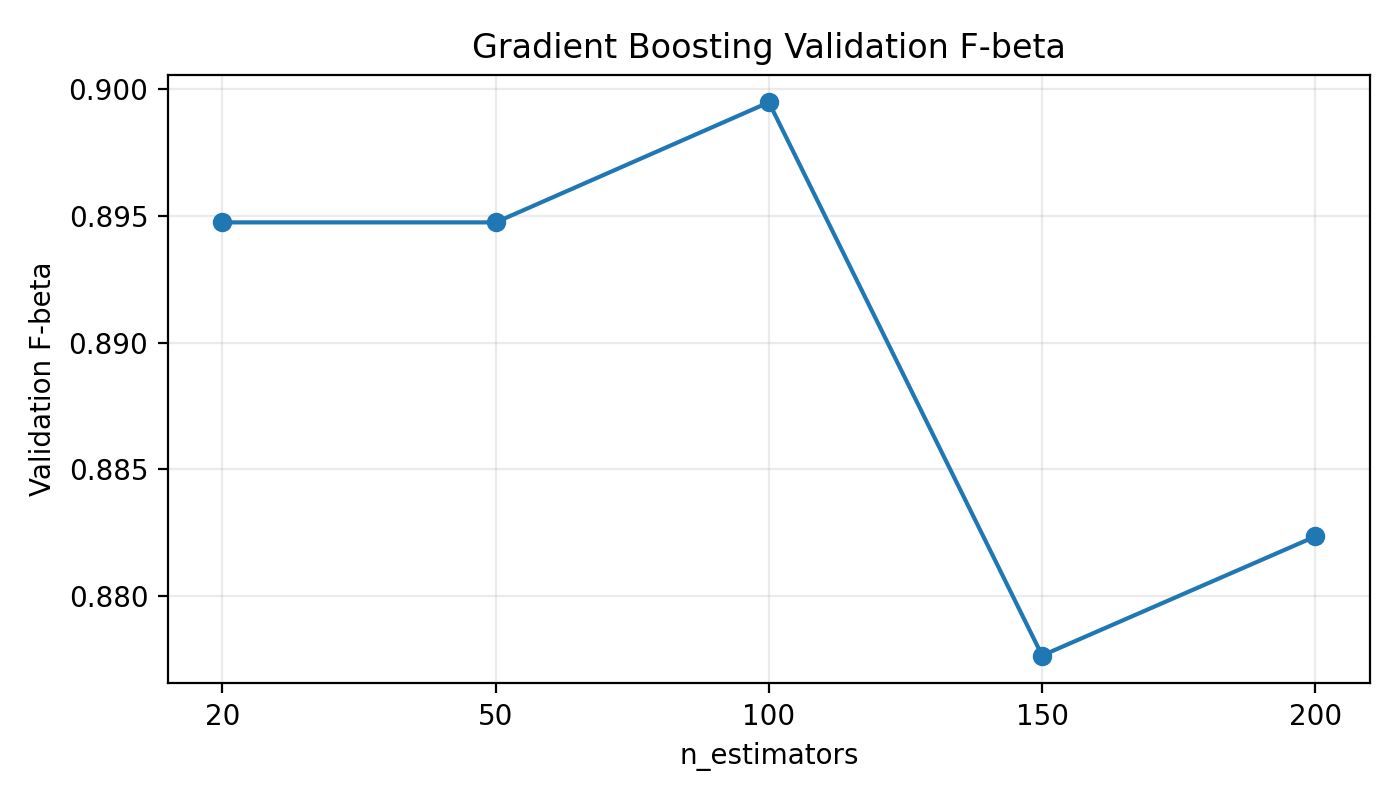

In [5]:
display(Image(filename=str(PROJECT_DIR / "figures" / "decision_tree_tuning.png")))

display(Image(filename=str(PROJECT_DIR / "figures" / "mlp_tuning.png")))

display(Image(filename=str(PROJECT_DIR / "figures" / "gradient_boosting_tuning.png")))

## Interpretable Small Tree

The reduced two-feature tree is useful because it makes the classification rule visually interpretable. The natural comparison is against a logistic model with the same two features.

In [6]:
table_3

,Model,Accuracy,Recall,Precision,F1,F_beta
0,Logit (2 features),0.8677,0.8571,0.3934,0.5393,0.6936
1,Decision Tree Small,0.8548,0.7857,0.3607,0.4944,0.6358


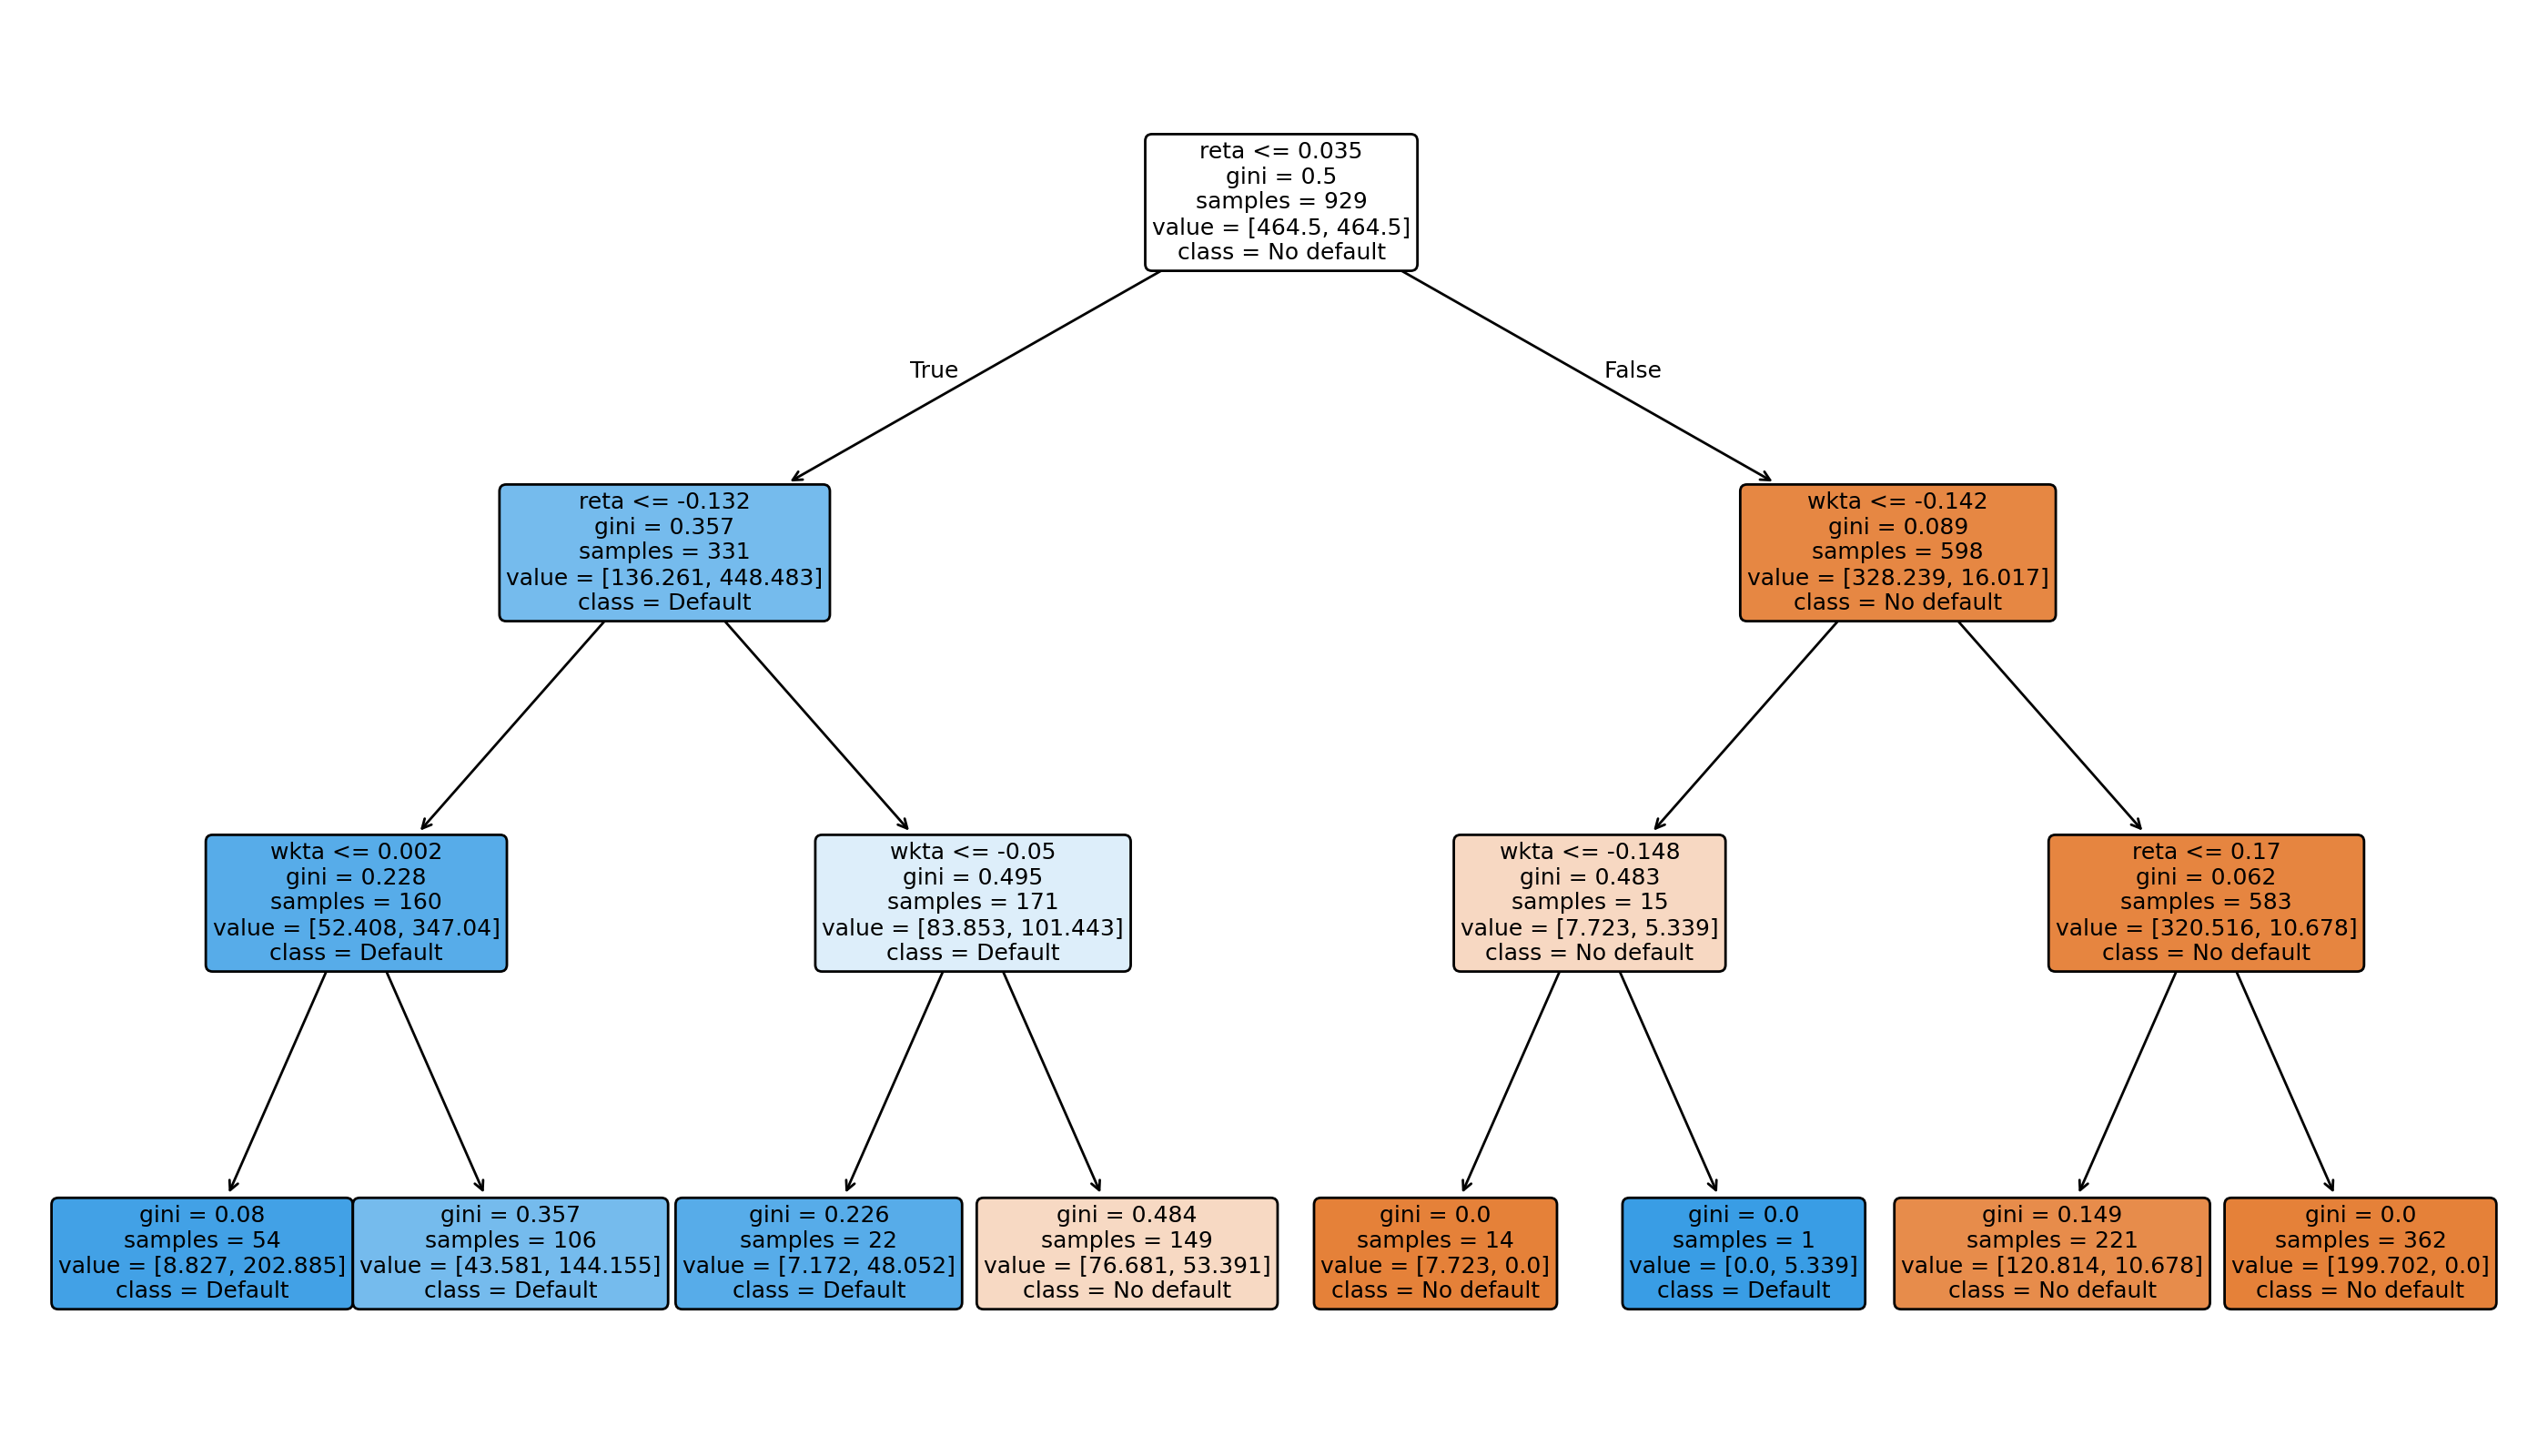

In [7]:
display(Image(filename=str(PROJECT_DIR / "figures" / "small_tree_plot.png")))

## Takeaways

- Logistic regression remains extremely competitive once the class imbalance is handled properly.
- The tuned neural network is close, but it does not clearly dominate the benchmark.
- The reduced two-feature tree is easy to interpret, but it does not beat the corresponding small logit.

So the main lesson of this dataset is that more flexible classifiers help only marginally when a small set of financial ratios already contains strong signal.